#   SPRINT 1: DATA UNDERSTANDING & PREPROCESSING


### importing libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#   Step 1: Data Collection & Loading


In [57]:
df = pd.read_csv("synthetic_disaster_events_2025 (1).csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (20000, 13)

Columns:
Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
       'date', 'severity_level', 'affected_population',
       'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
       'infrastructure_damage_index', 'is_major_disaster'],
      dtype='object')


- dataset contains 20000 rows and 13 columns
- Target variable identified as is_major_disaster

# Step 2 — Initial Data Inspection

In [58]:
df.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [59]:
df.tail()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
19995,19996,Volcanic Eruption,India,19.962542,82.590546,2025-11-16,6,28135,2556182.54,38.71,No,0.69,0
19996,19997,Volcanic Eruption,Japan,35.853659,138.522874,2025-04-08,2,4340,1228534.00,7.67,No,0.18,0
19997,19998,Hurricane,Philippines,13.720136,121.306074,2025-08-26,8,44663,8518260.66,9.76,Yes,0.75,1
19998,19999,Volcanic Eruption,India,19.959071,77.272460,2023-03-24,7,37484,10802942.53,13.87,Yes,0.77,1
19999,20000,Landslide,Chile,-36.842195,-68.613505,2023-04-05,6,34441,8966848.02,4.01,Yes,0.60,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

In [61]:
df.describe()

,event_id,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,infrastructure_damage_index,is_major_disaster
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000
mean,10000.500000,18.749811,41.976629,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005
std,5773.647028,25.026759,82.535922,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992
min,1.000000,-43.127383,-102.133704,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000
25%,5000.750000,3.560059,8.346726,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000
50%,10000.500000,24.361006,74.600322,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000
75%,15000.250000,38.285895,117.460836,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000
max,20000.000000,48.452161,145.902669,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000


In [62]:
df.isnull().sum()

event_id                       0
disaster_type                  0
location                       0
latitude                       0
longitude                      0
date                           0
severity_level                 0
affected_population            0
estimated_economic_loss_usd    0
response_time_hours            0
aid_provided                   0
infrastructure_damage_index    0
is_major_disaster              0
dtype: int64

- No missing values found 

In [63]:
df.duplicated().sum()

np.int64(0)

- No duplicates found

#   Step 3: Data Cleaning


In [64]:
df['date'] = pd.to_datetime(df['date'])

- Converts date from object to datetime format.

In [65]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

- creating date features into year,month,day
- may help to identify seasonal disaster patterns

In [66]:
df.drop('date', axis=1, inplace=True)

In [67]:
df.drop("event_id", axis=1, inplace=True)

- dropping oridinal date column  coz we have created date features seperately so it is no longer needed

In [68]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['disaster_type', 'location', 'latitude', 'longitude', 'severity_level',
       'affected_population', 'estimated_economic_loss_usd',
       'response_time_hours', 'aid_provided', 'infrastructure_damage_index',
       'is_major_disaster', 'year', 'month', 'day'],
      dtype='object')

# Step 4: Exploratory Data Analysis

# Univariate Analysis


### Disaster Type Distribution

In [69]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [70]:
cat_cols = df.select_dtypes(include='object').columns

# categorical column 

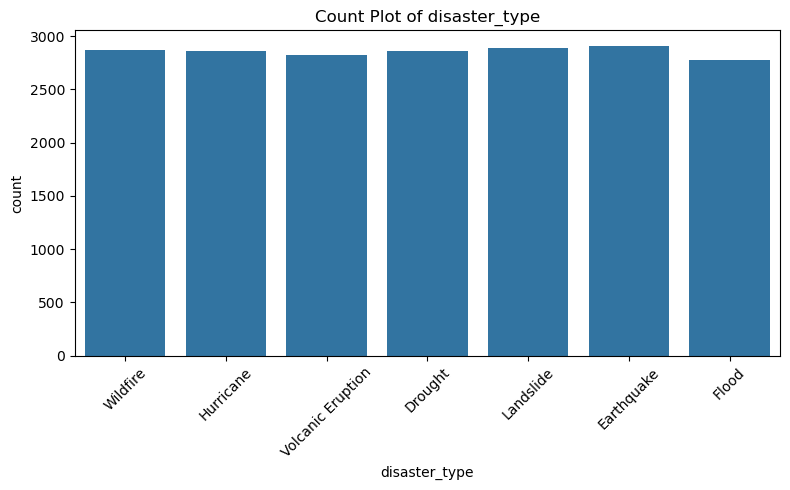

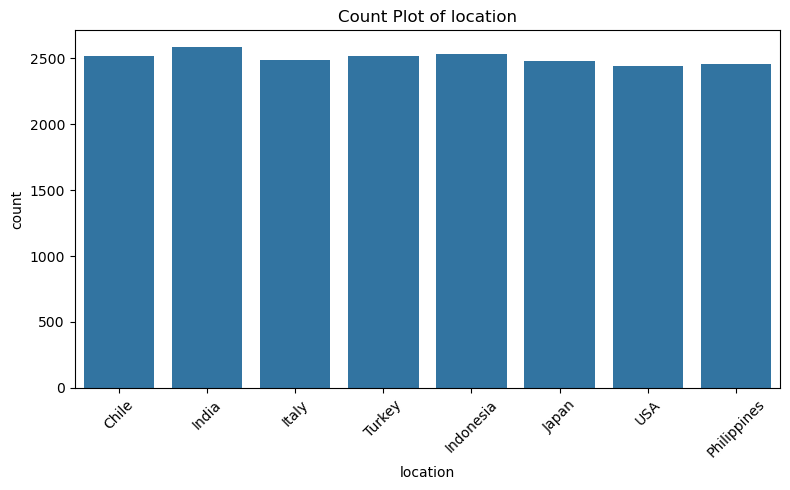

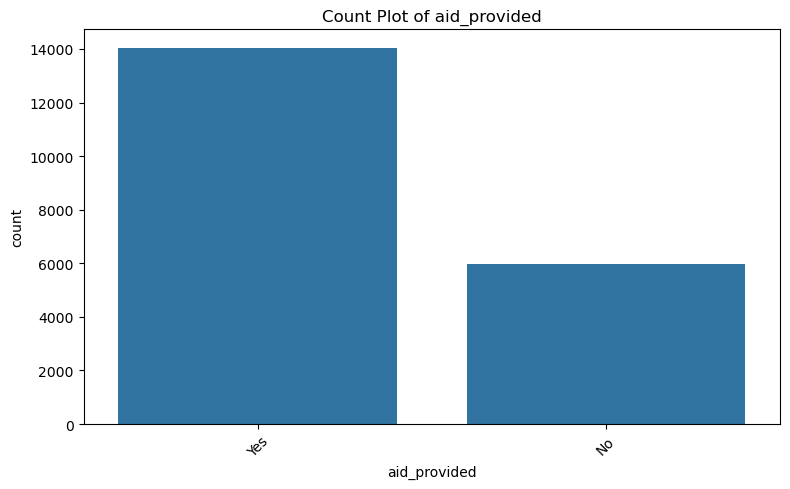

In [71]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Numerical Analysis

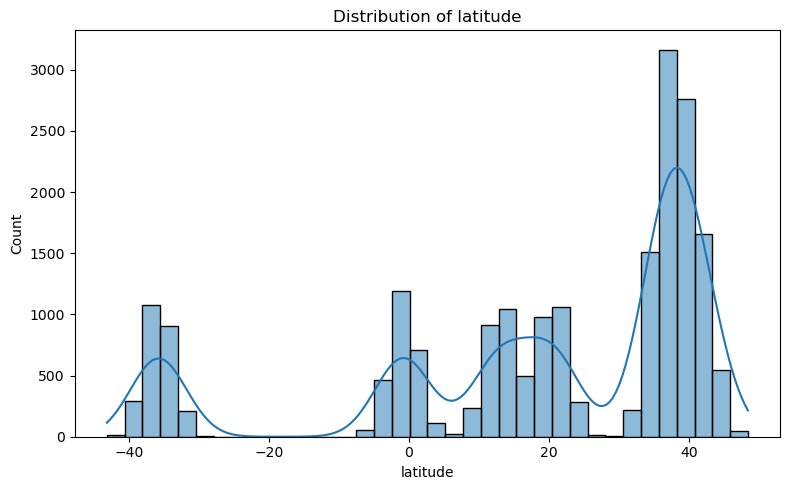

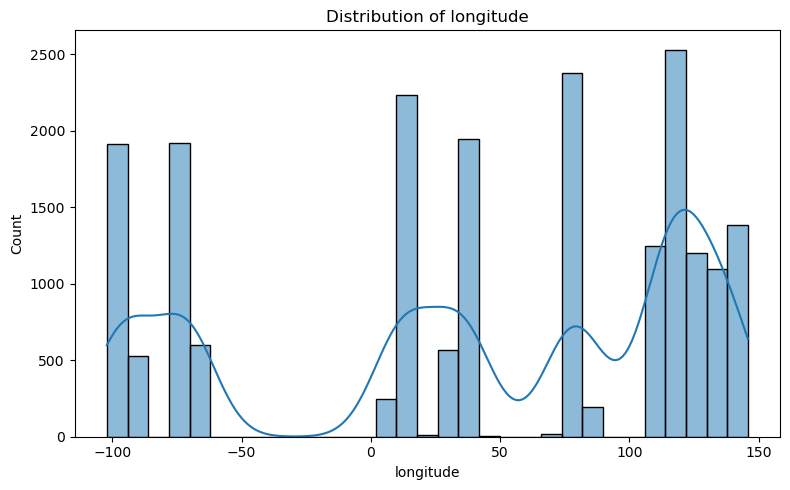

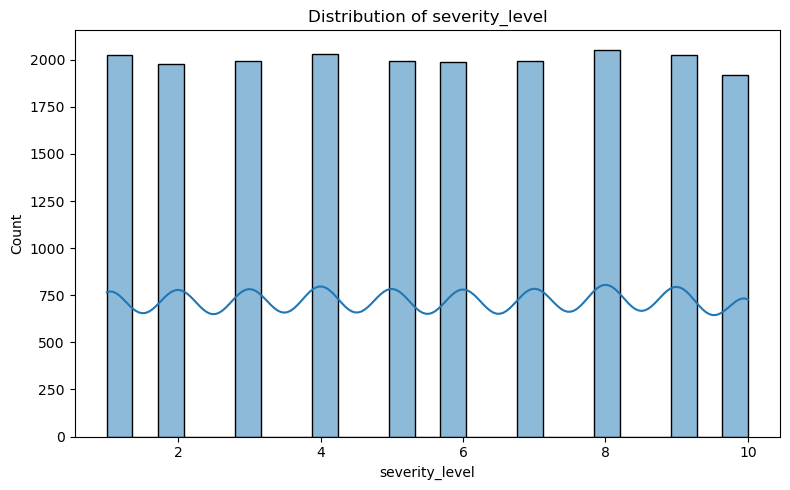

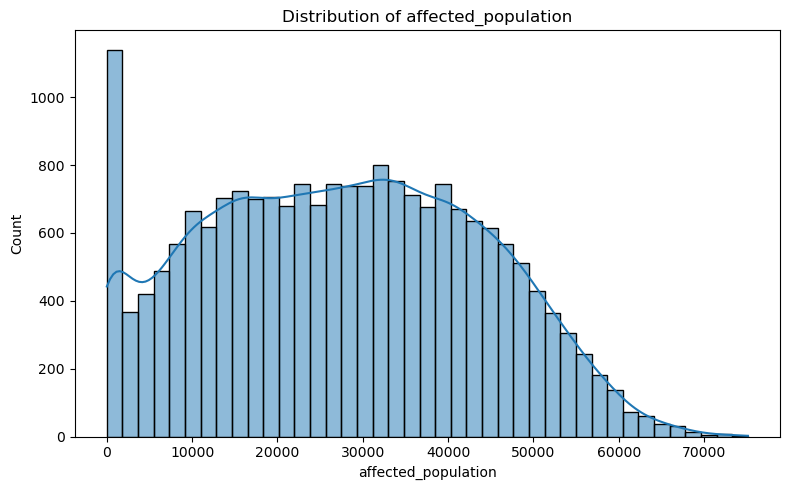

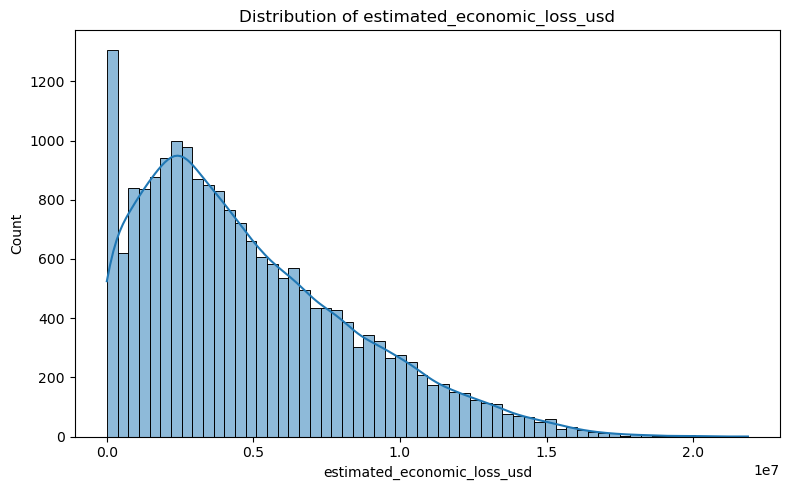

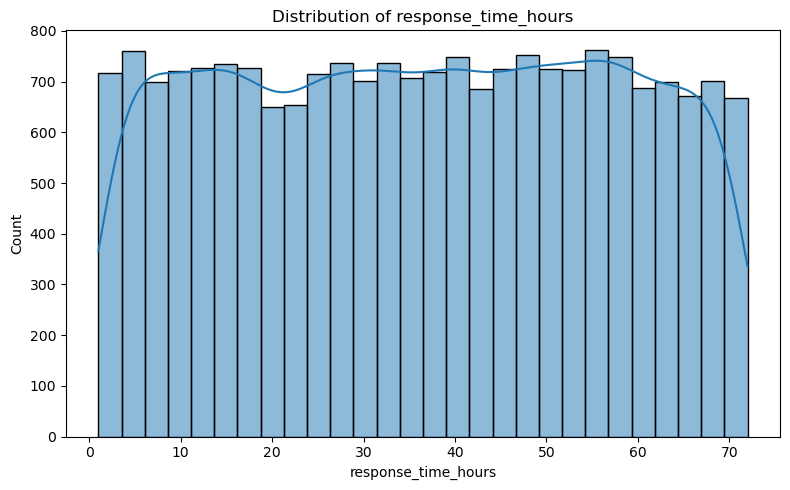

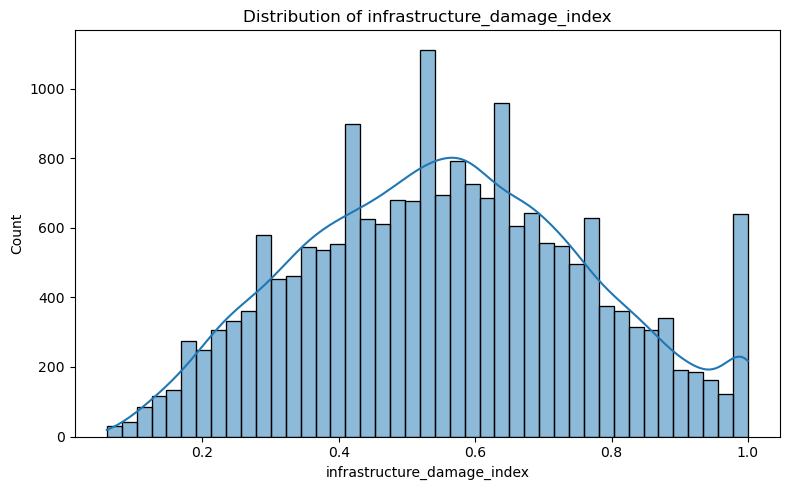

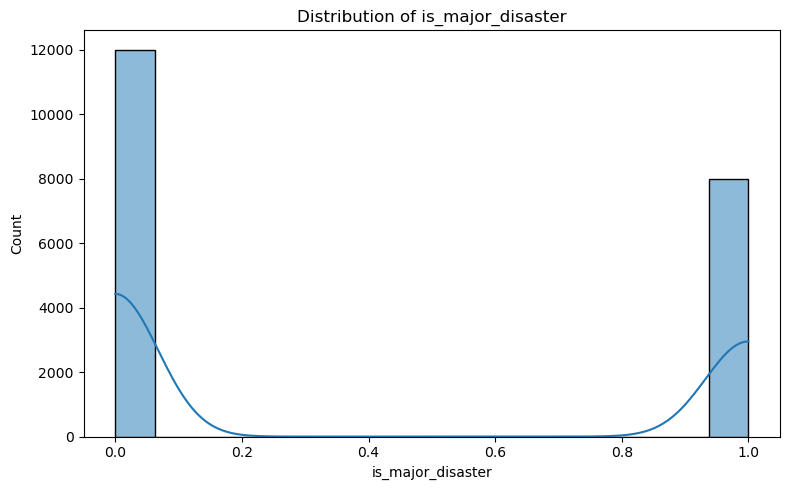

In [72]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# Target Variable Analysis
- is_major_disaster

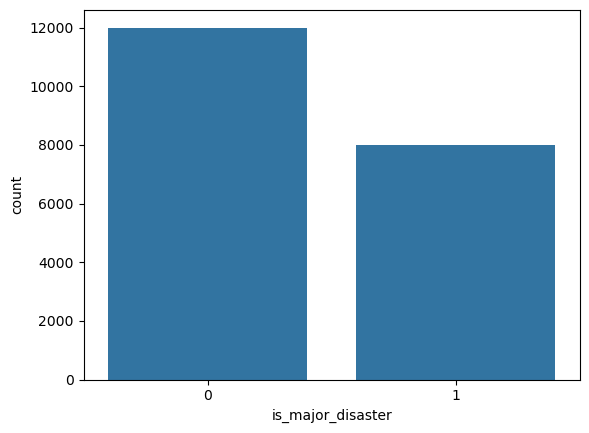

In [73]:
sns.countplot(x='is_major_disaster', data=df)
plt.show()

- Classes are reasonably balanced.
- No major class imbalance problem exists.
  

# Bivariate Analysis

### Severity vs Target
- is_major_disaster vs severity_level

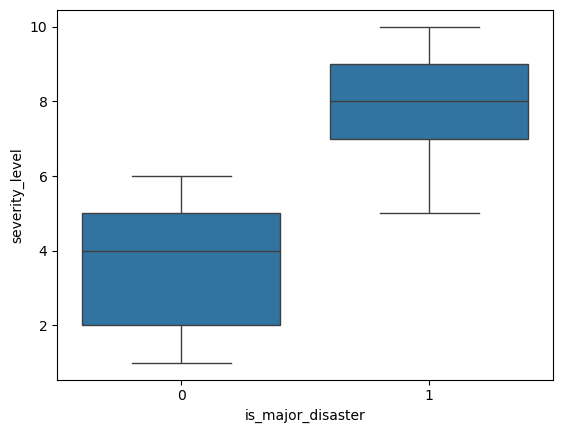

In [74]:
sns.boxplot(
    x='is_major_disaster',
    y='severity_level',
    data=df
)
plt.show()

# Affected Population vs Target
- is_major_disaster vs affected_population

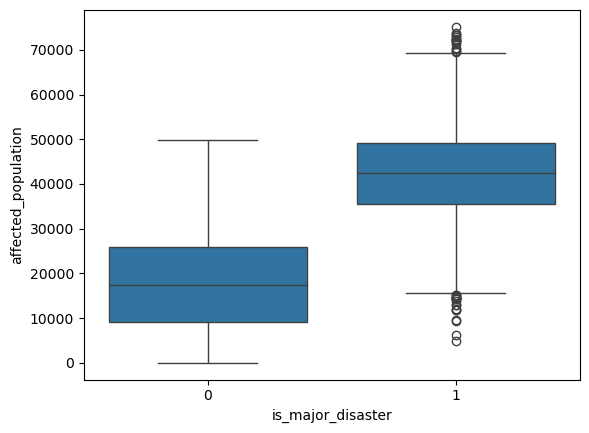

In [75]:
sns.boxplot(
    x='is_major_disaster',
    y='affected_population',
    data=df
)
plt.show()

- Correlation = 0.752
- Major disasters affect significantly more people.
- Population impact is a strong indicator of disaster severity.

# Economic Loss vs Target
- is_major_disaster  vs estimated_economic_loss_usd

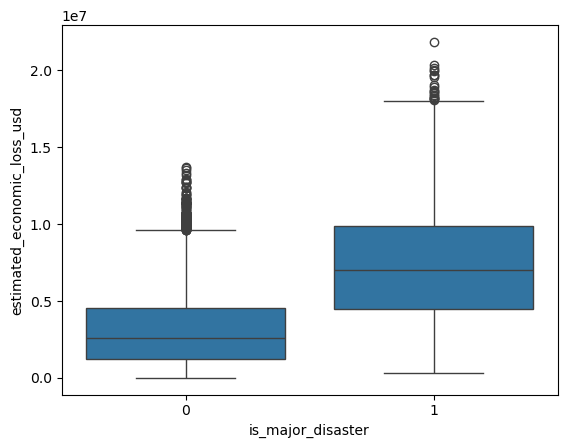

In [76]:
sns.boxplot(
    x='is_major_disaster',
    y='estimated_economic_loss_usd',
    data=df
)
plt.show()

- Correlation = 0.582
- Economic losses increase for major disasters.
- Financial damage contributes strongly to disaster classification.

# Multivariate Analysis


## Correlation Heatmap

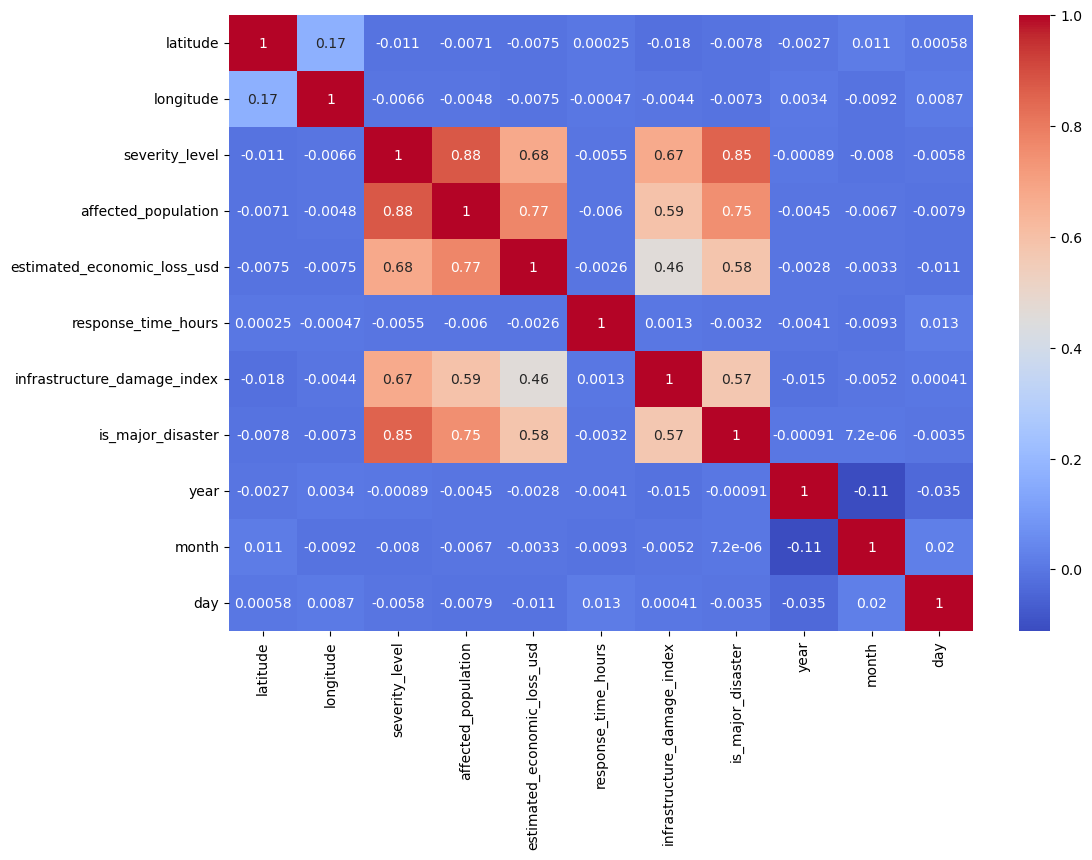

In [77]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Step 5: Outlier Detection

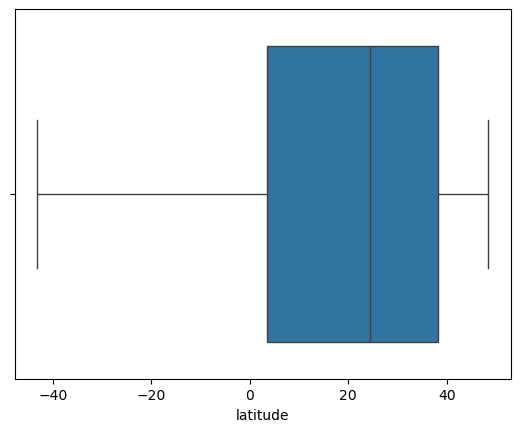

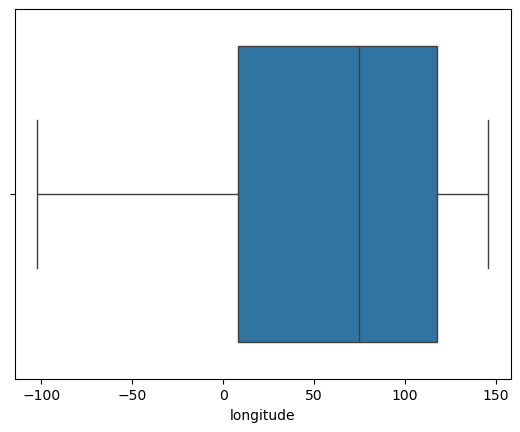

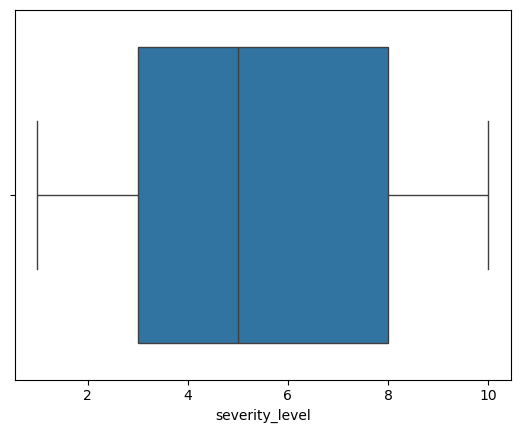

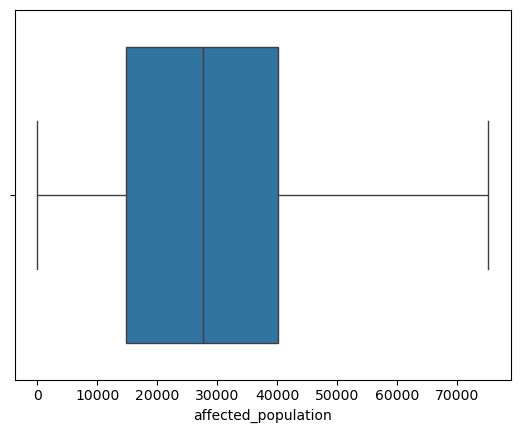

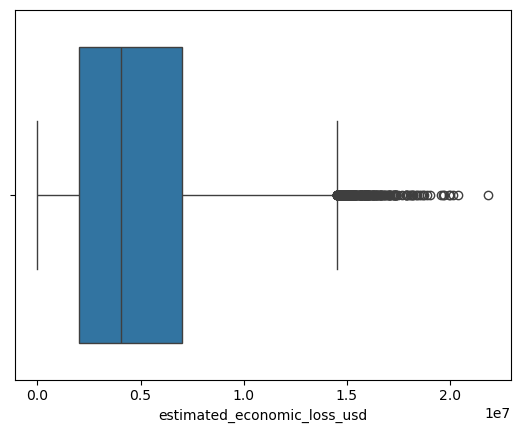

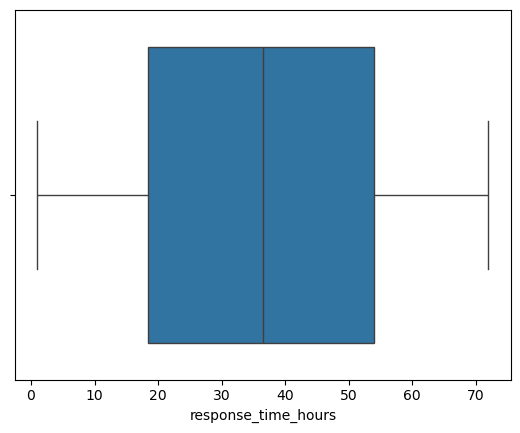

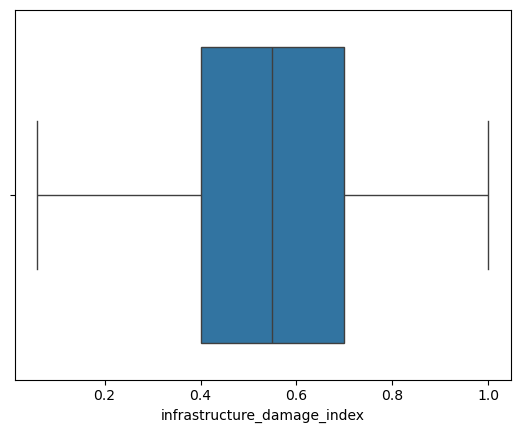

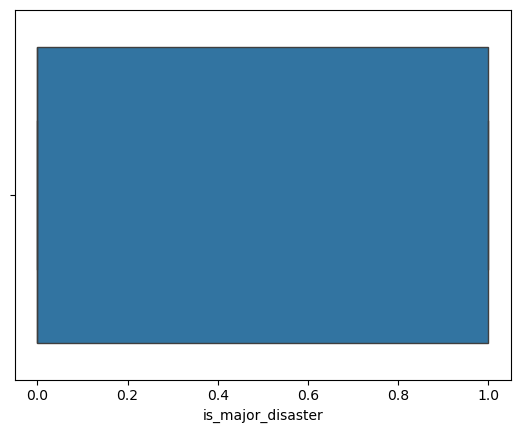

In [78]:


for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [79]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", outliers.shape[0])

latitude : 0
longitude : 0
severity_level : 0
affected_population : 0
estimated_economic_loss_usd : 268
response_time_hours : 0
infrastructure_damage_index : 0
is_major_disaster : 0


In [80]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

In [81]:
# after removing ouliers
for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", outliers.shape[0])

latitude : 0
longitude : 0
severity_level : 0
affected_population : 0
estimated_economic_loss_usd : 0
response_time_hours : 0
infrastructure_damage_index : 0
is_major_disaster : 0


# Step 6: Feature Encoding

In [82]:
# Check Unique Values
for col in cat_cols:

    print(col)

    print(df[col].unique())

    print("-------------------")

disaster_type
['Wildfire' 'Hurricane' 'Volcanic Eruption' 'Drought' 'Landslide'
 'Earthquake' 'Flood']
-------------------
location
['Chile' 'India' 'Italy' 'Turkey' 'Indonesia' 'Japan' 'USA' 'Philippines']
-------------------
aid_provided
['Yes' 'No']
-------------------


In [83]:
df.drop("response_time_hours", axis=1, inplace=True)
df.drop("day", axis=1, inplace=True)
df.drop("month", axis=1, inplace=True)
df.drop("year", axis=1, inplace=True)

In [84]:
X = df.drop('is_major_disaster', axis=1)
y = df['is_major_disaster']

In [85]:
from sklearn.base import BaseEstimator, TransformerMixin
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            self.freq_maps[col] = X[col].value_counts().to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
#categorical_cols = ['disaster_type','location']
#numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['latitude','longitude','severity_level','affected_population','estimated_economic_loss_usd','infrastructure_damage_index']),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['aid_provided']),
        ('freq', FrequencyEncoder(), ['disaster_type','location'])
    ]
)

In [87]:
df.head()


,disaster_type,location,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,aid_provided,infrastructure_damage_index,is_major_disaster
0,Wildfire,Chile,-34.681672,-71.819529,8.0,31104.0,2768213.39,Yes,0.59,1.0
1,Hurricane,India,22.128569,78.023951,5.0,29340.0,5996226.87,No,0.26,0.0
2,Volcanic Eruption,Italy,42.316058,11.031447,7.0,34804.0,9222541.48,No,0.94,1.0
3,Drought,Chile,-33.436253,-69.984615,8.0,31191.0,1827703.09,Yes,0.94,1.0
4,Volcanic Eruption,Turkey,39.400977,37.006822,8.0,46284.0,13435921.49,No,0.92,1.0


In [88]:
for col in cat_cols:

    print(col)

    print(df[col].unique())

    print("-------------------")

disaster_type
['Wildfire' 'Hurricane' 'Volcanic Eruption' 'Drought' 'Landslide'
 'Earthquake' 'Flood']
-------------------
location
['Chile' 'India' 'Italy' 'Turkey' 'Indonesia' 'Japan' 'USA' 'Philippines']
-------------------
aid_provided
['Yes' 'No']
-------------------


- All categorical variables are converted into numerical format for machine learning.

# Step 7: Train-Test Split

In [89]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [90]:
X.head()


,disaster_type,location,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,aid_provided,infrastructure_damage_index
0,Wildfire,Chile,-34.681672,-71.819529,8.0,31104.0,2768213.39,Yes,0.59
1,Hurricane,India,22.128569,78.023951,5.0,29340.0,5996226.87,No,0.26
2,Volcanic Eruption,Italy,42.316058,11.031447,7.0,34804.0,9222541.48,No,0.94
3,Drought,Chile,-33.436253,-69.984615,8.0,31191.0,1827703.09,Yes,0.94
4,Volcanic Eruption,Turkey,39.400977,37.006822,8.0,46284.0,13435921.49,No,0.92


In [91]:
y

0        1.0
1        0.0
2        1.0
3        1.0
4        1.0
        ... 
19995    0.0
19996    0.0
19997    1.0
19998    1.0
19999    0.0
Name: is_major_disaster, Length: 20000, dtype: float64

### Actual Dataset Split
- Training Records = 16,000
- Testing Records = 4,000

- 80% of the data is used for training and 20% for testing to evaluate model performance on unseen data.

# SPRINT 2: MODEL BUILDING & EVALUATION

### importing libraries

In [92]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

#   Step 1: Baseline Model


In [93]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred_train = lr_model.predict(X_train)
print("Test Classification Report Of Random Forest")
print(classification_report(y_test,lr_pred))
print("*" *20)
print("Train Classification Report Of Random Forest")
print(classification_report(y_train,lr_pred_train))

Test Classification Report Of Random Forest
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      2445
         1.0       0.99      0.99      0.99      1555

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

********************
Train Classification Report Of Random Forest
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      9554
         1.0       0.99      1.00      0.99      6446

    accuracy                           0.99     16000
   macro avg       0.99      0.99      0.99     16000
weighted avg       0.99      0.99      0.99     16000



c:\Users\katar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [94]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.992
Precision: 0.9859604339502234
Recall   : 0.9935691318327974
F1 Score : 0.9897501601537476


In [95]:
X_train

,disaster_type,location,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,aid_provided,infrastructure_damage_index
5894,Earthquake,India,17.989154,78.093816,5.0,35469.0,2.090962e+06,No,0.61
3728,Wildfire,USA,37.686022,-93.022614,4.0,20488.0,1.794522e+06,Yes,0.47
8958,Flood,Chile,-37.320851,-72.138818,2.0,10506.0,6.804110e+05,Yes,0.49
7671,Landslide,Turkey,41.152212,35.276938,10.0,42816.0,4.462222e+06,No,0.58
5999,Wildfire,Chile,-35.010835,-71.204114,6.0,41201.0,4.414310e+06,No,0.57
...,...,...,...,...,...,...,...,...,...
11284,Volcanic Eruption,Philippines,16.284619,123.825410,2.0,0.0,0.000000e+00,Yes,0.27
11964,Hurricane,India,23.095527,77.381413,2.0,11278.0,2.383972e+06,Yes,0.25
5390,Drought,Philippines,13.725848,122.225675,6.0,24568.0,2.734055e+06,Yes,0.70
860,Volcanic Eruption,Indonesia,-2.050942,117.605300,8.0,40891.0,4.632461e+06,Yes,0.84


# Step 2: Train Multiple Models

## Model 1: Decision Tree

In [96]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_pred_train = dt_model.predict(X_train)
print("Test Classification Report Of Decision Tree ")
print(classification_report(y_test,dt_pred))
print("*" *20)
print("Train Classification Report Of Decision Tree")
print(classification_report(y_train,dt_pred_train))

Test Classification Report Of Decision Tree 
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2445
         1.0       1.00      1.00      1.00      1555

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

********************
Train Classification Report Of Decision Tree
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9554
         1.0       1.00      1.00      1.00      6446

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



In [97]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Model 2: Random Forest

In [98]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_train = rf_model.predict(X_train)
print("Test Classification Report Of Random Forest")
print(classification_report(y_test,rf_pred))
print("*" *20)
print("Train Classification Report Of Random Forest")
print(classification_report(y_train,rf_pred_train))

Test Classification Report Of Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2445
         1.0       1.00      1.00      1.00      1555

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

********************
Train Classification Report Of Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9554
         1.0       1.00      1.00      1.00      6446

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



In [99]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9995
Precision: 1.0
Recall   : 0.9987138263665595
F1 Score : 0.9993564993564994


## Model 3: Support Vector Machine (SVM)

In [100]:
svc_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',SVC())
])

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)
svc_pred_train = svc_model.predict(X_train)
print("Test Classification Report Of svc")
print(classification_report(y_test,svc_pred))
print("*" *20)
print("Train Classification Report Of svc")
print(classification_report(y_train,svc_pred_train))

Test Classification Report Of svc
              precision    recall  f1-score   support

         0.0       0.61      1.00      0.76      2445
         1.0       0.00      0.00      0.00      1555

    accuracy                           0.61      4000
   macro avg       0.31      0.50      0.38      4000
weighted avg       0.37      0.61      0.46      4000

********************
Train Classification Report Of svc
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75      9554
         1.0       0.00      0.00      0.00      6446

    accuracy                           0.60     16000
   macro avg       0.30      0.50      0.37     16000
weighted avg       0.36      0.60      0.45     16000



c:\Users\katar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\katar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\katar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\katar\anaconda3\Lib\site-packag

In [101]:
print("Accuracy :", accuracy_score(y_test, svc_pred))
print("Precision:", precision_score(y_test, svc_pred))
print("Recall   :", recall_score(y_test, svc_pred))
print("F1 Score :", f1_score(y_test, svc_pred))

Accuracy : 0.61125
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


c:\Users\katar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model 4: Naive Bayes


In [102]:
nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',GaussianNB())
])

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_pred_train = nb_model.predict(X_train)
print("Test Classification Report Of GaussianNB ")
print(classification_report(y_test,nb_pred))
print("*" *20)
print("Train Classification Report Of Random Forest")
print(classification_report(y_train,nb_pred_train))

Test Classification Report Of GaussianNB 
              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96      2445
         1.0       0.93      0.96      0.95      1555

    accuracy                           0.96      4000
   macro avg       0.95      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000

********************
Train Classification Report Of Random Forest
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96      9554
         1.0       0.92      0.96      0.94      6446

    accuracy                           0.95     16000
   macro avg       0.95      0.95      0.95     16000
weighted avg       0.95      0.95      0.95     16000



In [103]:
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Accuracy : 0.9565
Precision: 0.9264978381717109
Recall   : 0.9646302250803859
F1 Score : 0.945179584120983


# Step 4: Overfitting & Underfitting Check

In [104]:
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svc_model,
    "Naive Bayes": nb_model
}

for name, model in models.items():

    train_acc = model.score(
        X_train,
        y_train
    )

    test_acc = model.score(
        X_test,
        y_test
    )

    print("\n", name)
    print("Training Accuracy:", round(train_acc,4))
    print("Testing Accuracy :", round(test_acc,4))


 Logistic Regression
Training Accuracy: 0.9946
Testing Accuracy : 0.992

 Decision Tree
Training Accuracy: 1.0
Testing Accuracy : 1.0

 Random Forest
Training Accuracy: 1.0
Testing Accuracy : 0.9995

 SVM
Training Accuracy: 0.5971
Testing Accuracy : 0.6112

 Naive Bayes
Training Accuracy: 0.9513
Testing Accuracy : 0.9565


# Step 5: Model Comparison Table

In [105]:
comparison_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'Naive Bayes'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svc_pred),
        accuracy_score(y_test, nb_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svc_pred),
        precision_score(y_test, nb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svc_pred),
        recall_score(y_test, nb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svc_pred),
        f1_score(y_test, nb_pred)
    ]
})

comparison_table.sort_values(
    by='Accuracy',
    ascending=False
)


c:\Users\katar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00000,1.000000,1.000000,1.000000
2,Random Forest,0.99950,1.000000,0.998714,0.999356
0,Logistic Regression,0.99200,0.985960,0.993569,0.989750
4,Naive Bayes,0.95650,0.926498,0.964630,0.945180
3,SVM,0.61125,0.000000,0.000000,0.000000


# hyper parameter Tuning

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8]
}

# Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search_dt.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

print("\nBest CV Score:")
print(grid_search_dt.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best CV Score:
0.9999375


In [107]:
from sklearn.metrics import classification_report, accuracy_score

best_dt = grid_search_dt.best_estimator_

# Predictions
train_pred = best_dt.predict(X_train)
test_pred = best_dt.predict(X_test)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nTrain Classification Report")
print(classification_report(y_train, train_pred))

print("\nTest Classification Report")
print(classification_report(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 1.0

Train Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9554
         1.0       1.00      1.00      1.00      6446

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000


Test Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2445
         1.0       1.00      1.00      1.00      1555

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [108]:
train_acc_dt = accuracy_score(y_train, train_pred)
test_acc_dt = accuracy_score(y_test, test_pred)

print("Decision Tree Train Accuracy:", train_acc_dt)
print("Decision Tree Test Accuracy:", test_acc_dt)

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 1.0


# SPRINT 3: OPTIMIZATION & FINAL MODEL

# Confusion Matrix

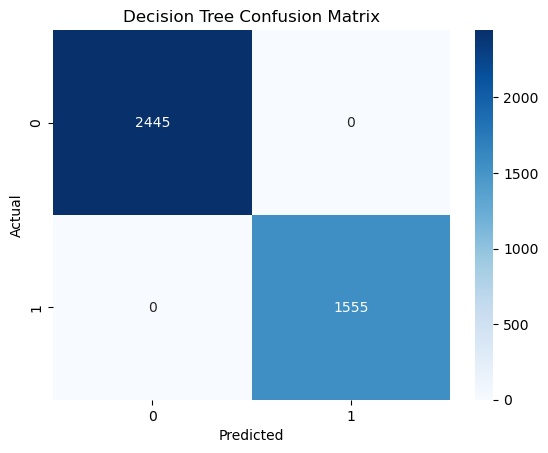

In [109]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    dt_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

#### The confusion matrix shows:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

# Classification Report

In [110]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2445
         1.0       1.00      1.00      1.00      1555

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



# Step 6: Model Serialization


## Objective :

Save the trained model so that it can be loaded later without retraining.

In [111]:
import pickle

with open('m_disaster_prediction_model.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

print("Model saved successfully!")

Model saved successfully!
